# ch239 — Hessians and Second-Order Methods

## Part VII — Calculus

Gradient descent uses only first-order information — the slope. But the slope alone 
does not tell you how quickly the landscape curves. Second-order methods use the 
**Hessian matrix** of second derivatives to adapt step sizes to the local curvature, 
converging far faster on well-conditioned problems.

*(Builds on ch217 — Second Derivatives, ch218 — Curvature, ch231 — Newton's Method, ch237 — Jacobians)*

## 1. The Hessian Matrix

For f: ℝⁿ → ℝ, the Hessian H is the n×n matrix of all second partial derivatives:

    H_ij = ∂²f / (∂xᵢ ∂xⱼ)

**Key properties:**
- H is symmetric (Schwarz's theorem: mixed partials commute)
- Eigenvalues of H determine curvature in each direction
- H positive definite  ⟺  local minimum
- H negative definite  ⟺  local maximum
- H indefinite         ⟺  saddle point *(ch214)*
- **Condition number** κ(H) = λ_max/λ_min controls convergence speed of gradient descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Analytical Hessian for f(x,y) = 3x^2 + xy + 2y^2
# df/dx = 6x + y,  df/dy = x + 4y
# H = [[d2f/dx2, d2f/dxdy], [d2f/dydx, d2f/dy2]] = [[6, 1], [1, 4]]

H_analytical = np.array([[6.0, 1.0], [1.0, 4.0]])
eigenvalues, eigenvectors = np.linalg.eigh(H_analytical)
print('Hessian H:')
print(H_analytical)
print(f'Eigenvalues: {eigenvalues}')
print(f'All positive => positive definite => local minimum')
print(f'Condition number: {eigenvalues[-1]/eigenvalues[0]:.2f}')

# Numerical Hessian via finite differences
def f(x):
    return 3*x[0]**2 + x[0]*x[1] + 2*x[1]**2

def numerical_hessian(f, x, h=1e-4):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n); ei[i] = h
            ej = np.zeros(n); ej[j] = h
            H[i,j] = (f(x+ei+ej) - f(x+ei-ej) - f(x-ei+ej) + f(x-ei-ej)) / (4*h*h)
    return H

x0 = np.array([1.0, 1.0])
H_numerical = numerical_hessian(f, x0)
print('\nNumerical Hessian:')
print(H_numerical.round(6))
print(f'Max error vs analytical: {np.max(np.abs(H_numerical - H_analytical)):.2e}')

Hessian H:
[[6. 1.]
 [1. 4.]]
Eigenvalues: [3.58578644 6.41421356]
All positive => positive definite => local minimum
Condition number: 1.79

Numerical Hessian:
[[6. 1.]
 [1. 4.]]
Max error vs analytical: 2.43e-08


## 2. Condition Number and Gradient Descent Convergence

The condition number κ = λ_max/λ_min of the Hessian determines convergence speed:
- κ = 1: perfectly round bowl, gradient descent converges in one step
- κ >> 1: elongated ellipse, gradient descent zigzags slowly

Optimal step size for gradient descent: α = 2/(λ_min + λ_max).  
Convergence rate per step: (κ-1)/(κ+1). For κ=100, this is 0.98 — 98% error remains each step.

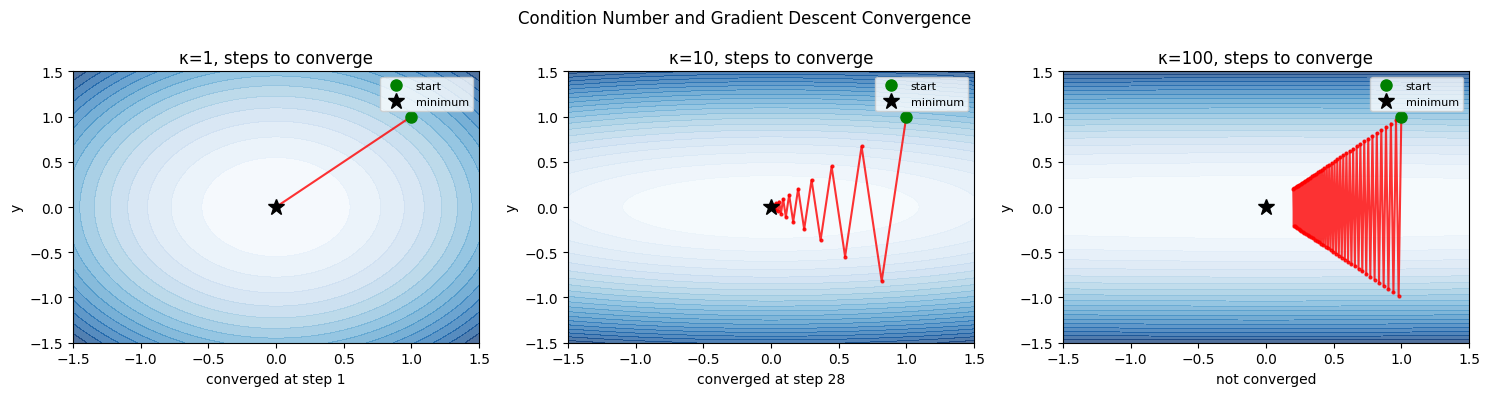

In [2]:
def run_gradient_descent(kappa, n_steps=80):
    # f(x,y) = (1/2)(x^2 + kappa*y^2)
    # gradient = [x, kappa*y]
    # Eigenvalues: 1 and kappa
    lam_min, lam_max = 1.0, float(kappa)
    alpha = 2.0 / (lam_min + lam_max)  # optimal step size
    x = np.array([1.0, 1.0])
    path = [x.copy()]
    losses = [0.5*(x[0]**2 + kappa*x[1]**2)]
    for _ in range(n_steps):
        grad = np.array([x[0], kappa*x[1]])
        x = x - alpha * grad
        path.append(x.copy())
        losses.append(0.5*(x[0]**2 + kappa*x[1]**2))
    return np.array(path), np.array(losses)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kappas = [1, 10, 100]
for ax, kappa in zip(axes, kappas):
    path, losses = run_gradient_descent(kappa)
    x_range = np.linspace(-1.5, 1.5, 200)
    y_range = np.linspace(-1.5, 1.5, 200)
    X2, Y2 = np.meshgrid(x_range, y_range)
    F2 = 0.5*(X2**2 + kappa*Y2**2)
    ax.contourf(X2, Y2, F2, levels=20, cmap='Blues', alpha=0.7)
    ax.plot(path[:,0], path[:,1], 'r.-', ms=4, lw=1.5, alpha=0.8)
    ax.plot(path[0,0], path[0,1], 'go', ms=8, label='start')
    ax.plot(0, 0, 'k*', ms=12, label='minimum')
    ax.set_title(f'κ={kappa}, steps to converge')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    # Count steps to reach loss < 1e-4
    converged = np.where(losses < 1e-4)[0]
    steps_str = f'converged at step {converged[0]}' if len(converged) else 'not converged'
    ax.set_xlabel(steps_str)

plt.suptitle('Condition Number and Gradient Descent Convergence', fontsize=12)
plt.tight_layout()
plt.savefig('ch239_condition.png', dpi=120)
plt.show()

## 3. Newton's Method in Multiple Dimensions

*(Newton's 1D method introduced in ch231)*

The multidimensional Newton update uses the Hessian inverse:

    x_{k+1} = x_k − H(x_k)⁻¹ ∇f(x_k)

This step maps the gradient into the geometry of the loss landscape — stretching the step 
in flat directions and shrinking it in steep ones. It eliminates the condition number problem: 
Newton's method converges in **one step** for any quadratic function, regardless of κ.

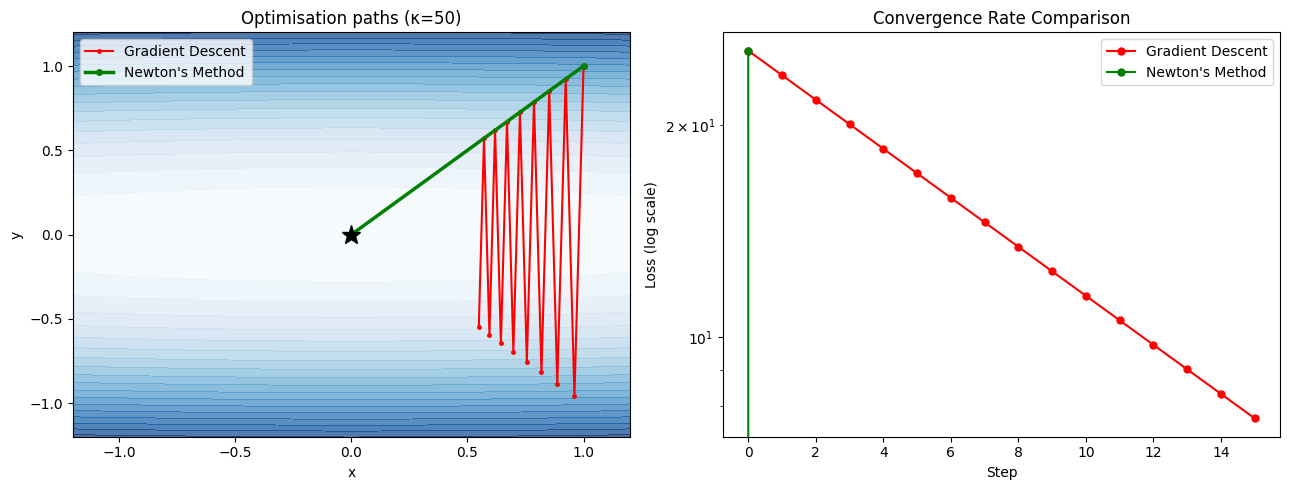

GD final loss:     7.68e+00
Newton final loss: 0.00e+00
Newton converges in 1 step for quadratics (exact Hessian), regardless of kappa.


In [3]:
def newton_vs_gd(kappa=50, n_steps=15):
    # f(x,y) = x^2/2 + kappa*y^2/2
    # grad = [x, kappa*y]
    # Hessian = diag(1, kappa)
    # Newton step: H^{-1} grad = [x, y]  (not kappa*y)
    alpha_gd = 2.0 / (1 + kappa)

    x_gd = np.array([1.0, 1.0])
    x_nt = np.array([1.0, 1.0])
    path_gd = [x_gd.copy()]
    path_nt = [x_nt.copy()]
    losses_gd = [0.5*(x_gd[0]**2 + kappa*x_gd[1]**2)]
    losses_nt = [0.5*(x_nt[0]**2 + kappa*x_nt[1]**2)]

    for _ in range(n_steps):
        # Gradient descent
        grad_gd = np.array([x_gd[0], kappa*x_gd[1]])
        x_gd = x_gd - alpha_gd * grad_gd
        path_gd.append(x_gd.copy())
        losses_gd.append(0.5*(x_gd[0]**2 + kappa*x_gd[1]**2))

        # Newton step (H^-1 = diag(1, 1/kappa))
        grad_nt = np.array([x_nt[0], kappa*x_nt[1]])
        H_inv = np.diag([1.0, 1.0/kappa])
        x_nt = x_nt - H_inv @ grad_nt
        path_nt.append(x_nt.copy())
        losses_nt.append(0.5*(x_nt[0]**2 + kappa*x_nt[1]**2))

    return (np.array(path_gd), np.array(losses_gd),
            np.array(path_nt), np.array(losses_nt))

path_gd, losses_gd, path_nt, losses_nt = newton_vs_gd(kappa=50)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Contour plot
kappa = 50
xr = np.linspace(-1.2, 1.2, 200)
yr = np.linspace(-1.2, 1.2, 200)
Xp, Yp = np.meshgrid(xr, yr)
Fp = 0.5*(Xp**2 + kappa*Yp**2)
axes[0].contourf(Xp, Yp, Fp, levels=20, cmap='Blues', alpha=0.7)
axes[0].plot(path_gd[:,0], path_gd[:,1], 'r.-', ms=5, lw=1.5, label='Gradient Descent')
axes[0].plot(path_nt[:,0], path_nt[:,1], 'g.-', ms=8, lw=2.5, label="Newton's Method")
axes[0].plot(0, 0, 'k*', ms=14)
axes[0].set_title(f'Optimisation paths (κ={kappa})')
axes[0].legend(); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Loss curves
axes[1].semilogy(losses_gd, 'r-o', ms=5, label='Gradient Descent')
axes[1].semilogy(losses_nt, 'g-o', ms=5, label="Newton's Method")
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Convergence Rate Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig('ch239_newton_vs_gd.png', dpi=120)
plt.show()
print(f'GD final loss:     {losses_gd[-1]:.2e}')
print(f"Newton final loss: {losses_nt[-1]:.2e}")
print("Newton converges in 1 step for quadratics (exact Hessian), regardless of kappa.")

## 4. Quasi-Newton Methods: BFGS

Computing and inverting H exactly costs O(n²) memory and O(n³) per step. For neural networks 
with millions of parameters, this is impossible.

**Quasi-Newton** methods approximate H⁻¹ using gradient history alone:
- **BFGS** (Broyden-Fletcher-Goldfarb-Shanno): maintains dense n×n approximation — good for n ≤ 10,000
- **L-BFGS** (Limited-memory BFGS): stores only the last m gradient differences (~20 vectors) — used in PyTorch's `torch.optim.LBFGS`

The key identity: if y = ∇f(x_new) − ∇f(x_old) and s = x_new − x_old, then H·s ≈ y (secant condition).

CG          :   38 iterations, final f=6.98e-17, x=[1. 1.]
BFGS        :   32 iterations, final f=8.84e-21, x=[1. 1.]
Nelder-Mead :  100 iterations, final f=4.06e-10, x=[1. 1.]


C:\Users\user\AppData\Local\Temp\ipykernel_16280\481117059.py:25: OptimizeWarning: Unknown solver options: gtol
  res = minimize(rosenbrock, x0, method=method, jac=jac,


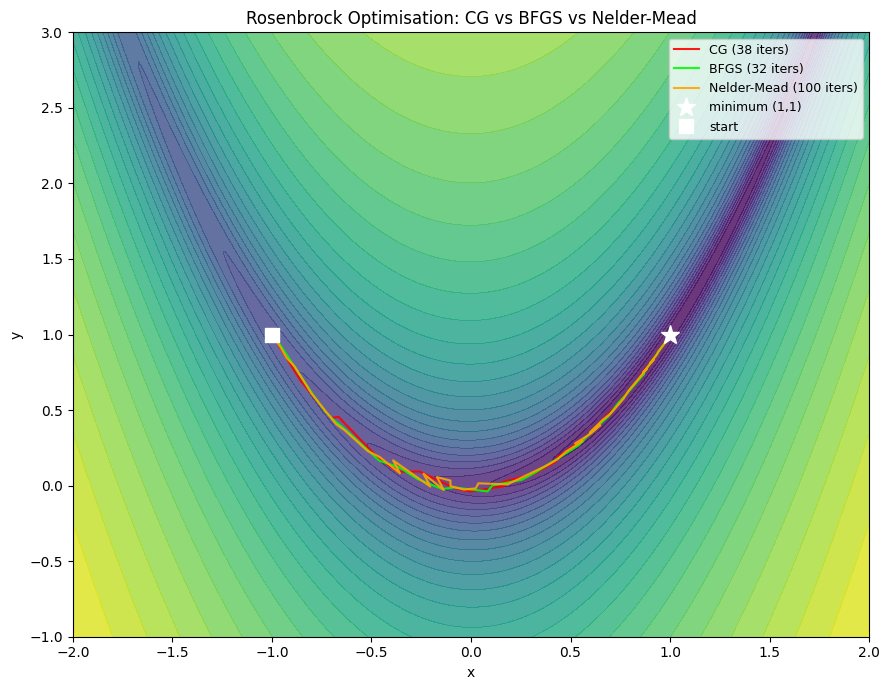

In [4]:
from scipy.optimize import minimize

# Rosenbrock function: classic ill-conditioned test case
# f(x,y) = (1-x)^2 + 100*(y-x^2)^2  minimum at (1,1)
def rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def rosenbrock_grad(x):
    dx = -2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2)
    dy = 200*(x[1]-x[0]**2)
    return np.array([dx, dy])

x0 = np.array([-1.0, 1.0])

# Track paths for different methods
methods = ['CG', 'BFGS', 'Nelder-Mead']
paths = {}
counts = {}

for method in methods:
    path_list = [x0.copy()]
    def callback(x):
        path_list.append(x.copy())
    jac = rosenbrock_grad if method != 'Nelder-Mead' else None
    res = minimize(rosenbrock, x0, method=method, jac=jac,
                   callback=callback, options={'maxiter': 2000, 'gtol': 1e-8})
    paths[method] = np.array(path_list)
    counts[method] = res.nit
    print(f'{method:12s}: {res.nit:4d} iterations, final f={res.fun:.2e}, x={res.x.round(4)}')

# Plot
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
Xr, Yr = np.meshgrid(x_range, y_range)
Fr = (1-Xr)**2 + 100*(Yr - Xr**2)**2

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(Xr, Yr, np.log1p(Fr), levels=30, cmap='viridis', alpha=0.8)
colors = ['red', 'lime', 'orange']
for (method, path), color in zip(paths.items(), colors):
    ax.plot(path[:,0], path[:,1], '-', color=color, lw=1.5, alpha=0.9,
            label=f'{method} ({counts[method]} iters)')
ax.plot(1, 1, 'w*', ms=14, label='minimum (1,1)')
ax.plot(x0[0], x0[1], 'ws', ms=10, label='start')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Rosenbrock Optimisation: CG vs BFGS vs Nelder-Mead')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ch239_bfgs.png', dpi=120)
plt.show()

## 5. Preconditioning: Making Gradient Descent Behave Like Newton

**Preconditioning** multiplies the gradient by a matrix P that approximates H⁻¹:

    x_{k+1} = x_k − P⁻¹ ∇f(x_k)

In deep learning, **Adam** is a diagonal preconditioner: it maintains an estimate of the 
second moment of each gradient coordinate and divides by its square root — approximately 
scaling by the inverse Hessian diagonal *(connects to ch291 — Optimisation Methods)*.

Condition number: 54.6


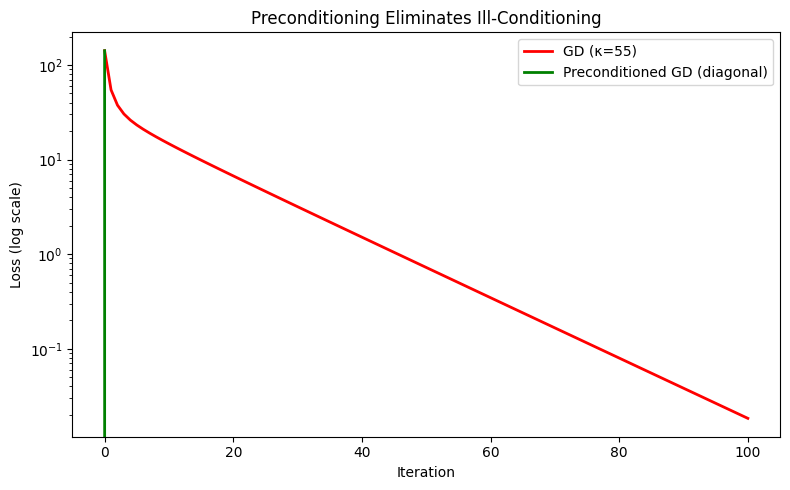

After 100 steps — Raw GD: 1.84e-02, Preconditioned: 0.00e+00


In [5]:
# Diagonal preconditioning vs raw gradient descent
# f(x) = sum_i (lambda_i * x_i^2 / 2)
# grad_i = lambda_i * x_i
# Preconditioned: divide grad_i by lambda_i -> uniform convergence

np.random.seed(0)
n = 20
lambdas = np.exp(np.linspace(0, 4, n))  # condition number = e^4 ~= 55
kappa_true = lambdas[-1] / lambdas[0]
print(f'Condition number: {kappa_true:.1f}')

def run_precond_gd(use_precond, n_steps=100):
    x = np.ones(n)
    alpha = 2.0 / (lambdas[0] + lambdas[-1])  # optimal for unpreconditioned
    losses = [0.5 * np.sum(lambdas * x**2)]
    for _ in range(n_steps):
        grad = lambdas * x
        if use_precond:
            step = grad / lambdas  # diagonal preconditioning
            x = x - step  # converges in 1 step for quadratic!
        else:
            x = x - alpha * grad
        losses.append(0.5 * np.sum(lambdas * x**2))
    return losses

losses_raw   = run_precond_gd(False)
losses_prec  = run_precond_gd(True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(losses_raw,  'r-', lw=2, label=f'GD (κ={kappa_true:.0f})')
ax.semilogy(losses_prec, 'g-', lw=2, label='Preconditioned GD (diagonal)')
ax.set_xlabel('Iteration'); ax.set_ylabel('Loss (log scale)')
ax.set_title('Preconditioning Eliminates Ill-Conditioning')
ax.legend()
plt.tight_layout()
plt.savefig('ch239_precond.png', dpi=120)
plt.show()
print(f'After 100 steps — Raw GD: {losses_raw[100]:.2e}, Preconditioned: {losses_prec[1]:.2e}')

## 6. Summary

| Concept | Key Insight |
|---------|------------|
| Hessian | Matrix of second derivatives; encodes curvature in all directions |
| Condition number κ | λ_max/λ_min; controls GD convergence rate |
| Newton's method | Uses H⁻¹; 1-step convergence on quadratics; O(n³) cost |
| BFGS | Approximates H⁻¹ from gradient differences; O(n²) memory |
| L-BFGS | Stores only last m vectors; practical for large models |
| Preconditioning | Multiply gradient by H⁻¹ approximation; Adam is diagonal preconditioning |

## 7. Forward References

- The Hessian diagonal connects to **Adam** and second-moment estimates in ch291 — Optimisation Methods.
- BFGS's secant condition mirrors the concept of **conjugate directions** used in conjugate gradient methods, 
relevant for large-scale linear systems in ch295 — Large Scale Data.
- Ill-conditioning of the Hessian is the core challenge in ch300 — Capstone: End-to-End AI System, 
where we compare optimisers on a real training problem.